In [1]:
from toy_data_flow import *
import torch

## Generate Data

In [3]:
gen = DoubleCircles()
dataTrain = gen.generate(n=100,T=1,dt=0.001,sigma=1.5)
dataTest = gen.generate(n=20,T=1,dt=0.001,sigma=1.5)

In [10]:
p = projection(origDim=2,newDim=3,projType='sigmoid',temp=3)

projectedTrain,projectedTest = [p.project(traj) for traj in dataTrain], [p.project(traj) for traj in dataTest]
dsTrain,dsTest = toyDataset(projectedTrain,dt=0.001,nForward=10),toyDataset(projectedTest,dt=0.001,nForward=10)
dls = {'train':torch.utils.data.DataLoader(dsTrain,batch_size=128,shuffle=True),'val': torch.utils.data.DataLoader(dsTest,batch_size=128,shuffle=False)}

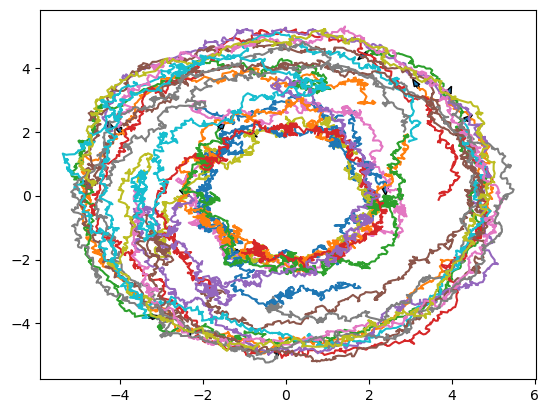

In [11]:
import matplotlib.pyplot as plt
ax = plt.gca()

for swirl in dataTest:
    ax.plot(swirl[:,0],swirl[:,1])
    #ax.scatter(swirl[-1,0],swirl[-1,1])
    #print(swirl.shape)
    dxy = np.diff(swirl,axis=0)
    #print(dxy.shape)
    ax.arrow(swirl[-1,0], swirl[-1,1],dxy[-1,0],dxy[-1,1],width=0.05)
plt.show()
plt.close()

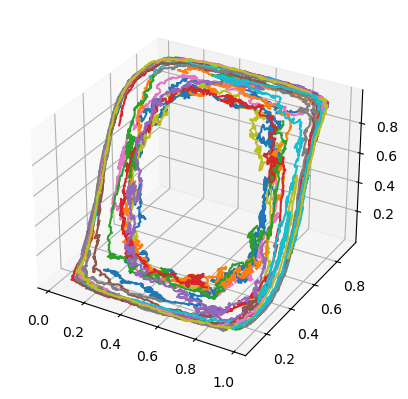

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

for swirl in projectedTest:
    ax.plot(swirl[:,0],swirl[:,1],swirl[:,2])
plt.show()
plt.close()

## Create Models

In [90]:
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from torch.distributions import LowRankMultivariateNormal
import os
from abc import ABC,abstractmethod



class AutoEncoder(nn.Module):

    def __init__(self,encoder,decoder,latent_model,save_dir='./autoencoder',loss_fn = nn.MSELoss(reduction='mean')):

        super(AutoEncoder,self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.latent_model=latent_model
        self.loss_fn = loss_fn
        self.save_dir=save_dir
        self.epoch=0
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.to(self.device)
        self.writer = SummaryWriter(log_dir=os.path.join(save_dir,'runs'))
        

    def encode(self,x):

        z = torch.vmap(self.encoder,in_dims=1,out_dims=1)(x)
        
        z,latent_reg = self.latent_model(z)

        return z,latent_reg

    def decode(self,z):

        return self.decoder(z)

    def forward(self,x):
        
        z,latent_reg = self.encode(x)

        xhat = self.decode(z)

        return xhat,latent_reg

    def train_epoch(self,loader,optimizer):

        tl = []
        for ii,batch in enumerate(loader,start=len(loader)*self.epoch):

            optimizer.zero_grad()
            
            data,dt= batch[:-1],batch[-1]
            data = torch.stack(data,axis=1).to(self.device)

            xhat,latent_reg = self.forward(data)
            if xhat.shape[1] < data.shape[1]:
                recon_loss = self.loss_fn(xhat,data[:,1:,...])

            else:
                recon_loss = self.loss_fn(xhat,data)
            loss = latent_reg + recon_loss
            loss.backward()
            optimizer.step()

            self.writer.add_scalar('Train/recon loss',recon_loss.item(),ii)
            self.writer.add_scalar('Train/latent regularization',latent_reg.item(),ii)
            tl.append(loss.item())
        self.epoch += 1

        return tl,optimizer

    def val_epoch(self,loader):

        vl = []
        reg = []
        recon = []
        with torch.no_grad():

            for batch in loader:
                data,dt= batch[:-1],batch[-1]
                
                data = torch.stack(data,axis=1).to(self.device)
                xhat,latent_reg = self.forward(data)
                if xhat.shape[1] < data.shape[1]:
                    recon_loss = self.loss_fn(xhat,data[:,1:,...])
    
                else:
                    recon_loss = self.loss_fn(xhat,data)
        
                loss = recon_loss + latent_reg
                vl.append(loss.item())
                reg.append(latent_reg.item())
                recon.append(recon_loss.item())
            self.writer.add_scalar('Val/recon loss',np.nanmean(recon),self.epoch)
            self.writer.add_scalar('Val/latent regularization',np.nanmean(reg),self.epoch)

        return vl

    def save(self,optimizer):

        state_dict_full = {'model_dict':self.state_dict(),'opt_dict':optimizer.state_dict(),'epoch':self.epoch}
        torch.save(state_dict_full,os.path.join(self.save_dir,f'checkpoint_{self.epoch}.tar'))

    def load(self,path,optimizer):

        state_dict = torch.load(path)
        optimizer.load_state_dict(state_dict['opt_dict'])
        self.load_state_dict(state_dict['model_dict'])
        self.epoch = state_dict['epoch']
        return optimizer
            
class LatentLSTM(nn.Module):
    
    def __init__(self,input_size,hidden_size,num_layers,loss_fn=nn.MSELoss(reduction='mean')):

        super().__init__()

        self.net = nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers,batch_first=True)
        self.output = nn.Linear(hidden_size,input_size)
        self.loss_fn = loss_fn

    def forward(self,x):

        x,y = x[:,:-1,...],x[:,1:,...]
        out,_ = self.net(x)
        yhat = self.output(out)
        return yhat,self.loss_fn(yhat,y)

class LatentVAE(nn.Module):
    
    def __init__(self,input_size,output_size,num_hidden,hidden_size=10):

        super().__init__()

        self.mu = [nn.Linear(input_size,hidden_size,bias=True), nn.ReLU()]
        self.u = [nn.Linear(input_size,hidden_size,bias=True),nn.ReLU()]
        self.d = [nn.Linear(input_size,hidden_size,bias=True),nn.ReLU()]
        for _ in range(num_hidden):
            self.mu.append(nn.Linear(hidden_size,hidden_size))
            self.mu.append(nn.ReLU())
            self.u.append(nn.Linear(hidden_size,hidden_size))
            self.u.append(nn.ReLU())
            self.d.append(nn.Linear(hidden_size,hidden_size))
            self.d.append(nn.ReLU())
        self.mu.append(nn.Linear(hidden_size,output_size))
        self.u.append(nn.Linear(hidden_size,output_size))
        self.d.append(nn.Linear(hidden_size,output_size))

        self.mu = nn.Sequential(*self.mu)
        self.u = nn.Sequential(*self.u)
        self.d = nn.Sequential(*self.d)

    def forward(self,x):

        mu,u,d = self.mu(x),self.u(x),self.d(x)
        u = u.unsqueeze(-1)
        d = torch.exp(d)
        
        latent_dist = LowRankMultivariateNormal(mu, u, d)
        z = latent_dist.rsample()
        
        kl_term = -0.5 * (torch.sum(torch.pow(z,2)) + z.shape[-1] * np.log(2*np.pi))
        kl_term = kl_term + torch.sum(latent_dist.entropy())
        
        return z,kl_term


class Encoder(nn.Module):
    
    def __init__(self):

        super().__init__()

        
    @abstractmethod
    def forward(self,x):
        raise NotImplementedError


class Decoder(nn.Module):

    def __init__(self):

        super().__init__()

    @abstractmethod
    def forward(self,x):
        raise NotImplementedError

class Linear(Encoder,Decoder):

    def __init__(self,in_dim,out_dim,has_bias=True):

        super(LinearDecoder,self).__init__()

        self.net = nn.Linear(in_dim,out_dim,bias=has_bias)

    def forward(self,x):
        return self.net(x)

    

class CirclePredictor(nn.Module):

    def __init__(self,input_size,hidden_size,num_layers,save_dir='./circle_model',loss_fn = nn.MSELoss(reduction='mean')):

        super().__init__()

        self.lstm = nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers)
        self.output = nn.Linear(hidden_size,input_size)

        self.save_dir=save_dir
        if not os.path.isdir(save_dir):
            os.mkdir(save_dir)
        self.loss_fn = loss_fn

        self.epoch = 0
        if torch.cuda.is_available(): 
            self.device='cuda' 
            self.to(torch.device('cuda'))
        else:
            self.device='cpu'
        self.writer = SummaryWriter(log_dir=os.path.join(save_dir,'runs'))
        
    def forward(self,x):

        output,(h_n,c_n) = self.lstm(x)

        output = self.output(output)

        return output,(h_n,c_n)

    def train_epoch(self, loader, optimizer):

        optimizer.zero_grad()
        tl = []
        for ii,batch in enumerate(loader,start=self.epoch*len(loader)):

            data,dt= batch[:-1],batch[-1]
            #print(batch)
            x,y = torch.stack(data[:-1],axis=1).to(self.device),torch.stack(data[1:],axis=1).to(self.device)
            out,(h_n,c_n) = self.forward(x)

            train_loss = self.loss_fn(out,y)
            train_loss.backward()
            optimizer.step()
            self.writer.add_scalar('Train/loss',train_loss.item(),ii)
            tl.append(train_loss.item())

        self.epoch += 1

        return tl,optimizer

    def val_epoch(self,loader):

        vl = []
        with torch.no_grad():

            for batch in loader:
                data,dt= batch[:-1],batch[-1]
                
                x,y = torch.stack(data[:-1],axis=1).to(self.device),torch.stack(data[1:],axis=1).to(self.device)
                out,(h_n,c_n) = self.forward(x)
    
                val_loss = self.loss_fn(out,y)
                vl.append(val_loss.item())
            self.writer.add_scalar('Val/loss',np.nanmean(vl),self.epoch)

        return vl

    def save(self,optimizer):

        state_dict_full = {'model_dict':self.state_dict(),'opt_dict':optimizer.state_dict(),'epoch':self.epoch}
        torch.save(state_dict_full,os.path.join(self.save_dir,f'checkpoint_{self.epoch}.tar'))

    def load(self,path,optimizer):

        state_dict = torch.load(path)
        optimizer.load_state_dict(state_dict['opt_dict'])
        self.load_state_dict(state_dict['model_dict'])
        self.epoch = state_dict['epoch']
        return optimizer

            
            
        

In [91]:
from torch.optim import Adam
enc = nn.Sequential(*[nn.Linear(3,2,bias=True),
                     nn.ReLU(),
                     nn.Linear(2,2,bias=True),
                     nn.ReLU(),
                     nn.Linear(2,2,bias=True)])
dec = nn.Sequential(*[nn.Linear(2,2,bias=True),
                     nn.ReLU(),
                     nn.Linear(2,2,bias=True),
                     nn.ReLU(),
                     nn.Linear(2,3,bias=True)])
latent_model = LatentVAE(input_size=2,output_size=2,num_hidden=1,hidden_size=2)

ac = AutoEncoder(enc,dec,latent_model=latent_model,save_dir='/home/miles/isilon/All_Staff/miles/models/circle_vae_ac_nonlinear')

opt = Adam(ac.parameters(),lr=1e-4)

In [88]:
batch = next(iter(dls['train']))
b = torch.stack(batch[:-1],axis=1).to(ac.device)
c = ac(b)

In [30]:
print(b.shape,c[0].shape)

torch.Size([128, 11, 3]) torch.Size([128, 10, 3])


## Train

In [63]:
from tqdm import tqdm
def train(model,optimizer,loaders,nEpochs=100,save_freq=25):

    train_losses,test_losses,val_losses = [],[],[]
    for epoch in tqdm(range(nEpochs),desc='training model'):

        model.train()

        train_loss,optimizer = model.train_epoch(loaders['train'],optimizer)

        model.eval()
        val_loss = model.val_epoch(loaders['val'])

        if epoch % save_freq == 0:
            model.save(optimizer)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    return train_losses,test_losses,model,optimizer


def predict(model,trajectory):

    model.eval()
    trajectory = torch.from_numpy(trajectory).type(torch.FloatTensor).to(model.device)[None,...]
    #print(trajectory.shape)
    x = trajectory[:,:-1,...]
    y = trajectory[:,1:,...]

    
    yhat,_ = model(x)

    return yhat.detach().cpu().numpy().squeeze()


def embed(model,trajectory):

    model.eval()
    trajectory = torch.from_numpy(trajectory).type(torch.FloatTensor).to(model.device)[None,...]
    #print(trajectory.shape)
    #z = torch.vmap(model.encoder,in_dims=1,out_dims=1)(trajectory)
    #print(z.shape)
    x = trajectory[:,:-1,...]
    y = trajectory[:,1:,...]

    yhat,_ = model.encode(x)
    return yhat.detach().cpu().numpy().squeeze()

In [95]:
train_loss,test_loss,model,opt = train(ac,opt,dls)

training model: 100%|███████████████████| 100/100 [47:23<00:00, 28.43s/it]


## Evaluate

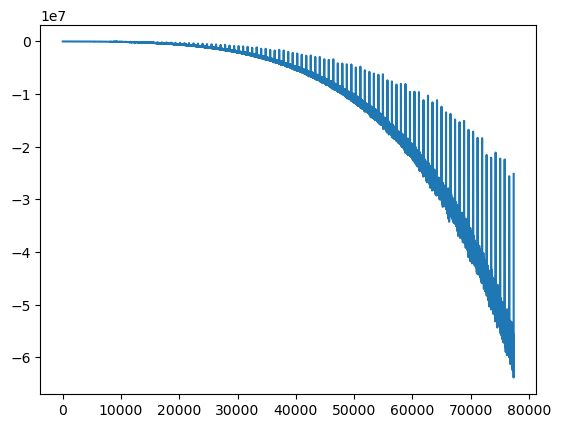

In [96]:
ax = plt.gca()
ax.plot(np.hstack(train_loss))
plt.show()
plt.close()

In [70]:
pred_test = [predict(model,traj) for traj in projectedTest]
latents_test = [embed(model,traj) for traj in projectedTest]

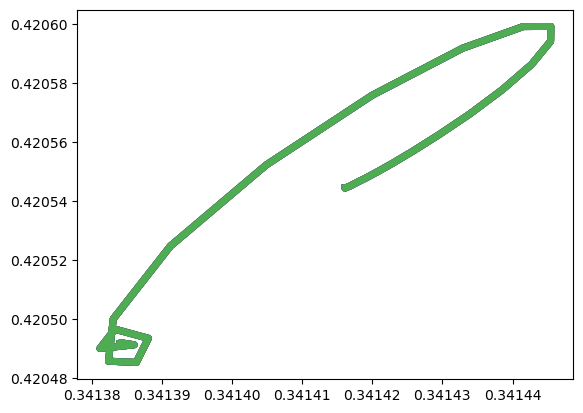

"    \nfig,axs = plt.subplots(nrows=1,ncols=2)\nfor true,pred,color in zip(dataTest,pred_test,colornames):\n    #print(pred.shape)\n    true = true[1:]\n    errors = true - pred\n    axs[0].plot(errors[:,0],errors[:,1],color=color,linestyle='solid',linewidth=1.5,alpha=1)\n    #axs[0].plot(pred[:,0],pred[:,1],color=color,linestyle='solid',linewidth=5,alpha=0.75)\n    axs[1].plot(np.linalg.norm(errors,axis=1),color=color)\n\nplt.show()\nplt.close()\n"

In [71]:
import matplotlib.colors as mcolors
colornames = list(mcolors.XKCD_COLORS.keys())
ax = plt.gca()
for true,pred,color in zip(dataTest,latents_test,colornames):
    #print(pred.shape)
    true = true[1:]
    #ax.plot(true[:,0],true[:,1],color=color,linestyle='solid',linewidth=1.5,alpha=1)
    ax.plot(pred[:,0],pred[:,1],color=color,linestyle='solid',linewidth=5,alpha=0.75)

plt.show()
plt.close()



In [73]:
print(pred_test[0].shape)

(998, 3)


[0.50289154 0.54815286 0.58932368]
[0.49458197 0.5030629  0.5037319 ]
[0.51442182 0.50764382 0.51939187]
[0.49458197 0.5030629  0.5037319 ]
[0.5029543  0.53945842 0.56355   ]
[0.49458197 0.5030629  0.5037319 ]
[0.45696312 0.48802273 0.50584175]
[0.49458197 0.5030629  0.5037319 ]
[0.48335266 0.47684077 0.44441849]
[0.49458197 0.5030629  0.5037319 ]
[0.55835489 0.50435761 0.48742216]
[0.49458197 0.5030629  0.5037319 ]
[0.47371639 0.50805691 0.4983634 ]
[0.49458197 0.5030629  0.5037319 ]
[0.49378058 0.47593771 0.47151981]
[0.49458197 0.5030629  0.5037319 ]
[0.51847122 0.50043766 0.49041882]
[0.49458197 0.5030629  0.5037319 ]
[0.5275331  0.51197731 0.51661306]
[0.49458197 0.5030629  0.5037319 ]
[0.56441368 0.45998408 0.42761954]
[0.49458197 0.5030629  0.5037319 ]
[0.55181512 0.48376884 0.42636523]
[0.49458197 0.5030629  0.5037319 ]
[0.44312981 0.43397078 0.37718856]
[0.49458197 0.5030629  0.5037319 ]
[0.527845   0.49198596 0.48005887]
[0.49458197 0.5030629  0.5037319 ]
[0.50202178 0.412778

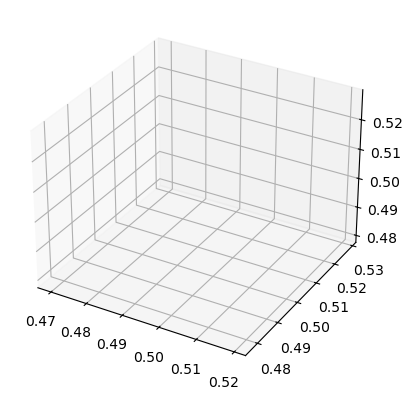

In [77]:
colornames = list(mcolors.XKCD_COLORS.keys())
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
for true,pred,color in zip(projectedTest,pred_test,colornames):
    #print(pred.shape)
    true = true[1:]
    print(np.nanmean(true,axis=0))
    print(pred[0])
    #ax.plot(true[:,0],true[:,1],color=color,linestyle='solid',linewidth=1.5,alpha=1)
    ax.plot(pred[:,0],pred[:,1],pred[:,2],color=color,linestyle='solid',linewidth=5,alpha=0.75)

plt.show()
plt.close()